# Analysing Results

## Training & Validation Loss
Comparing Training Loss and Validation Loss against Epochs for different models and companies

In [1]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt

CLASSIFICATION_RESULTS_PATH = Path("results/benchmarking/classification/")
REGRESSION_RESULTS_PATH = Path("results/benchmarking/regression/")

### Average Across All Tickers

#### Classification 

In [3]:
import numpy as np

models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
results = []

for model_name in models:
    csv_path = Path.joinpath(CLASSIFICATION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)

    df = df.sort_values(by="epoch")

    auc_train = np.trapezoid(df["train_loss"], df["epoch"])
    auc_val = np.trapezoid(df["val_loss"], df["epoch"])

    results.append({
        "Model": model_name,
        "AUC_Train": auc_train,
        "AUC_Validation": auc_val
    })

results_df = pd.DataFrame(results)
print(results_df)

FileNotFoundError: [Errno 2] No such file or directory: 'results/benchmarking/classification/LSTM_loss_curves.csv'

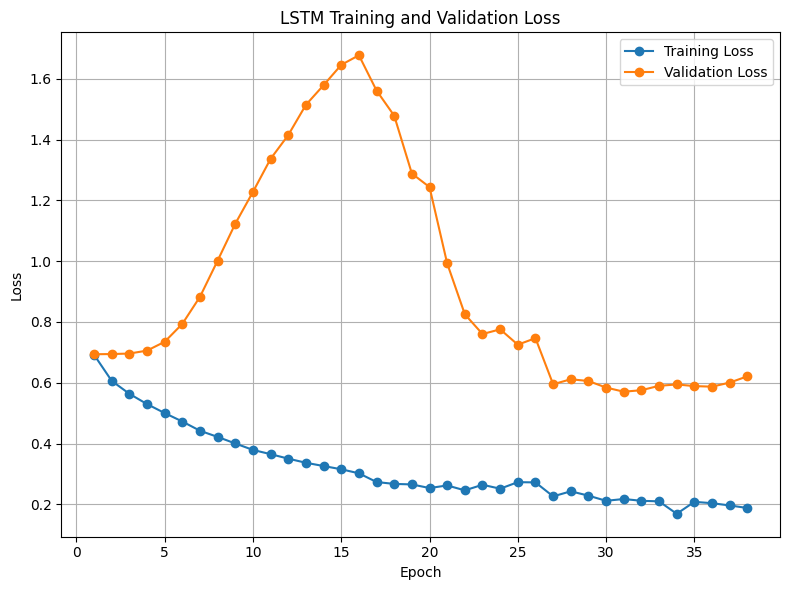

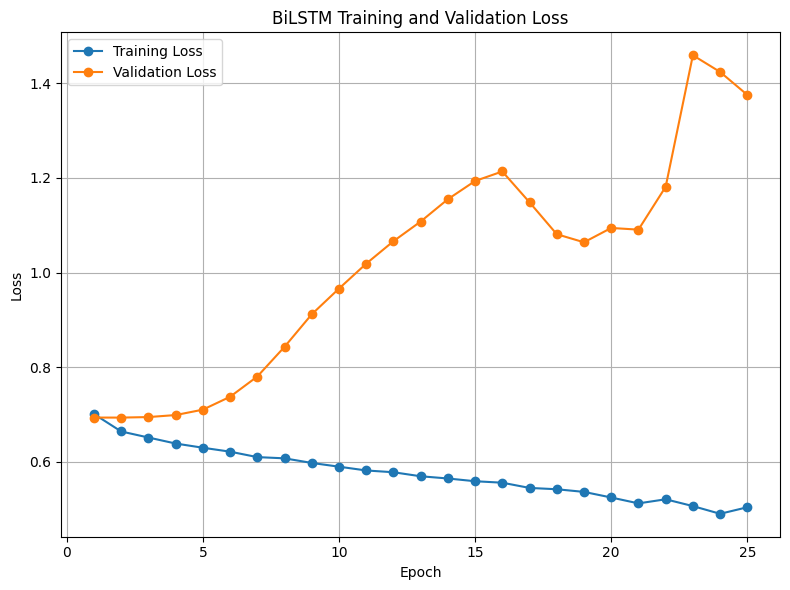

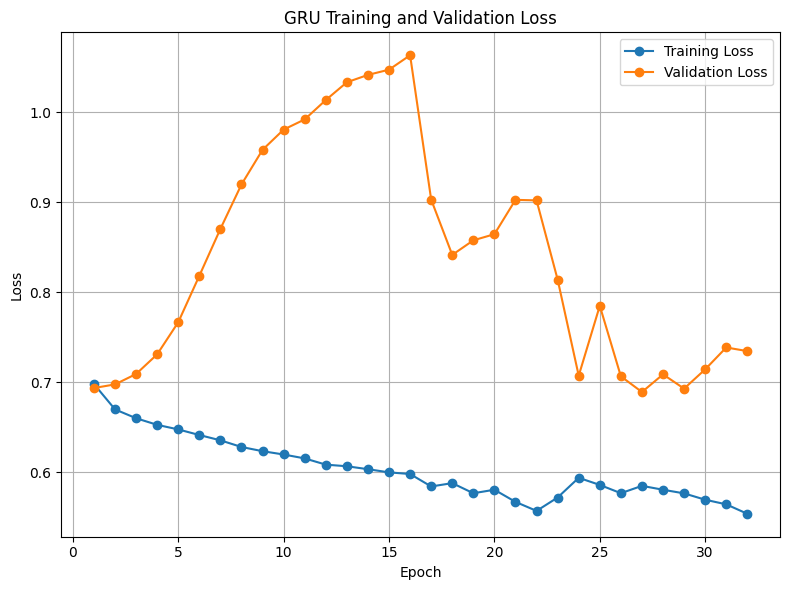

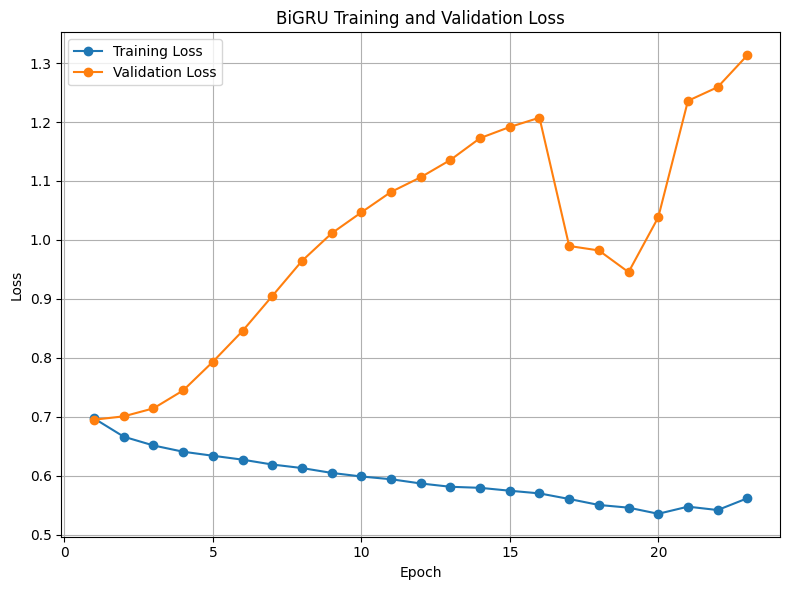

In [ ]:
for i, model_name in enumerate(models):
    csv_path = Path.joinpath(CLASSIFICATION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)

    average_class_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(average_class_loss["epoch"], average_class_loss["train_loss"], label="Training Loss", marker='o')
    ax.plot(average_class_loss["epoch"], average_class_loss["val_loss"], label="Validation Loss", marker='o')
    ax.set_title(f"{model_name} Training and Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

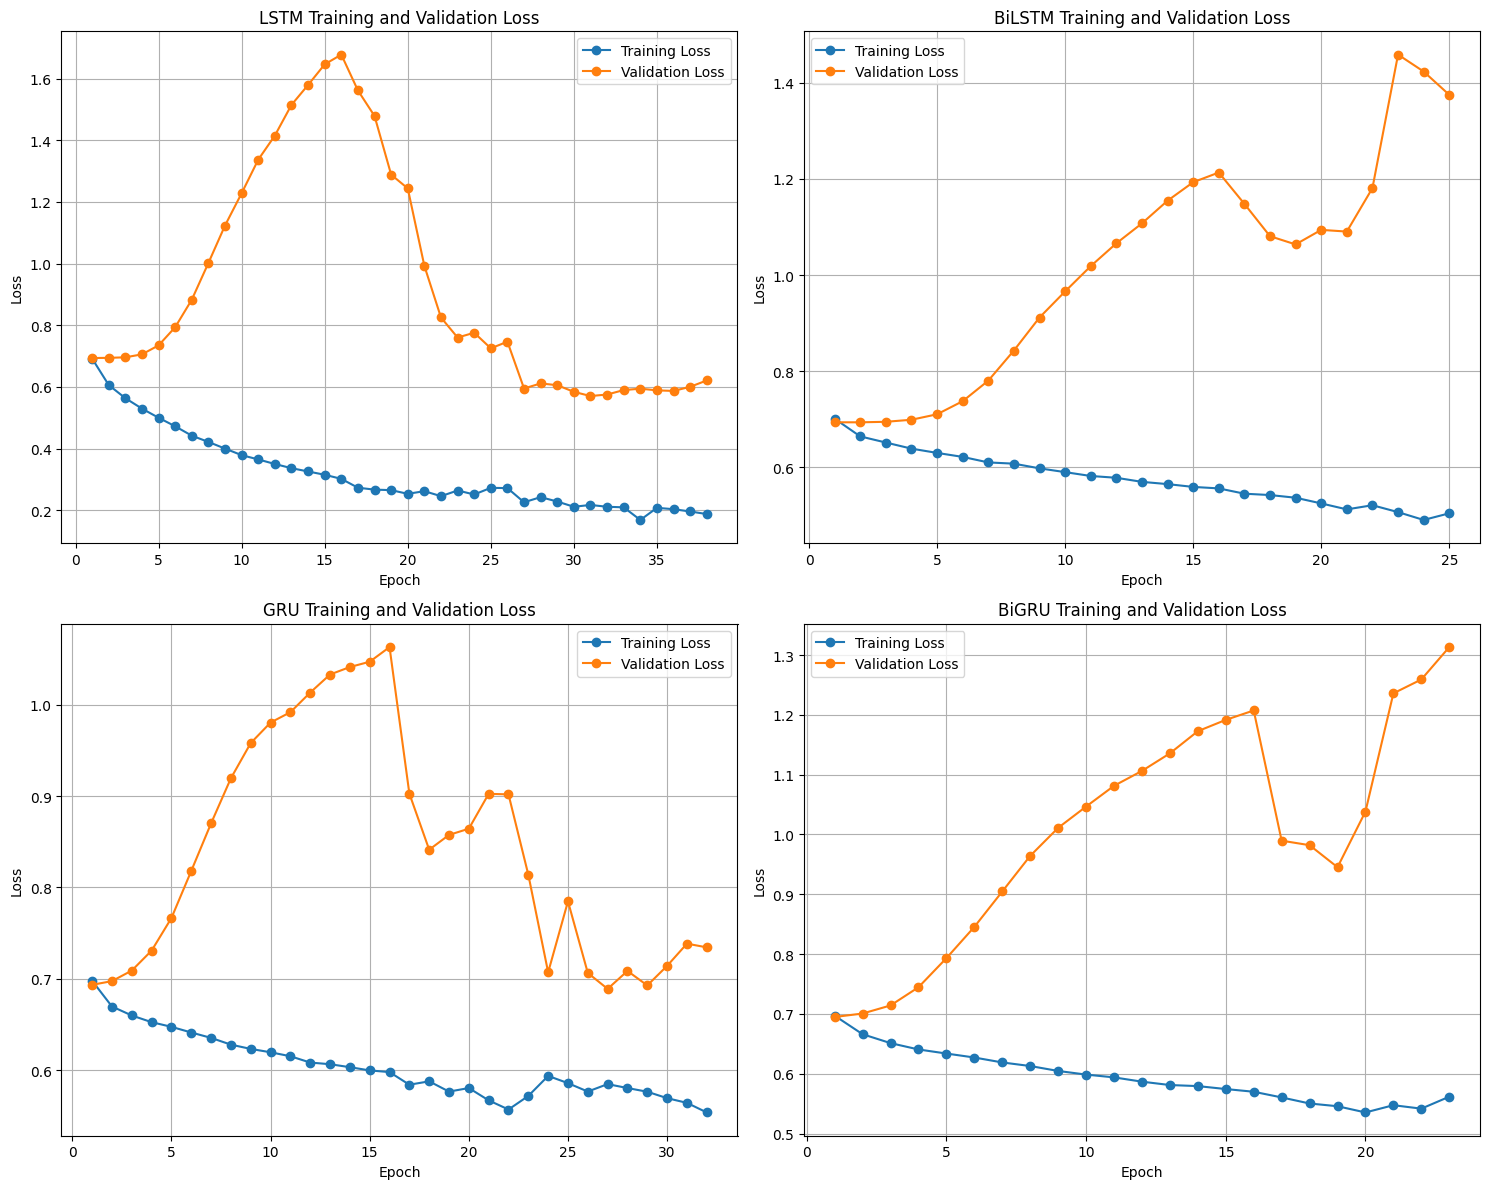

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(15, 12)) 
axes = axes.flatten()

for i, model_name in enumerate(models):
    csv_path = Path.joinpath(CLASSIFICATION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)
    
    average_class_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()
    
    axes[i].plot(average_class_loss["epoch"], average_class_loss["train_loss"], label="Training Loss", marker='o')
    axes[i].plot(average_class_loss["epoch"], average_class_loss["val_loss"], label="Validation Loss", marker='o')
    axes[i].set_title(f"{model_name} Training and Validation Loss")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

#### Regression

In [ ]:
import numpy as np

models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]
results = []

for model_name in models:
    csv_path = Path.joinpath(REGRESSION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)

    # Ensure the DataFrame is sorted by epoch
    df = df.sort_values(by="epoch")

    # Compute area under the curve for training and validation loss
    auc_train = np.trapezoid(df["train_loss"], df["epoch"])
    auc_val = np.trapezoid(df["val_loss"], df["epoch"])

    results.append({
        "Model": model_name,
        "AUC_Train": auc_train,
        "AUC_Validation": auc_val
    })
# Output the results
results_df = pd.DataFrame(results)
print(results_df)

    Model  AUC_Train  AUC_Validation
0    LSTM   8.723420       18.411046
1  BiLSTM  11.288284       23.135899
2     GRU  12.316795       25.997299
3   BiGRU   8.454432       18.798095


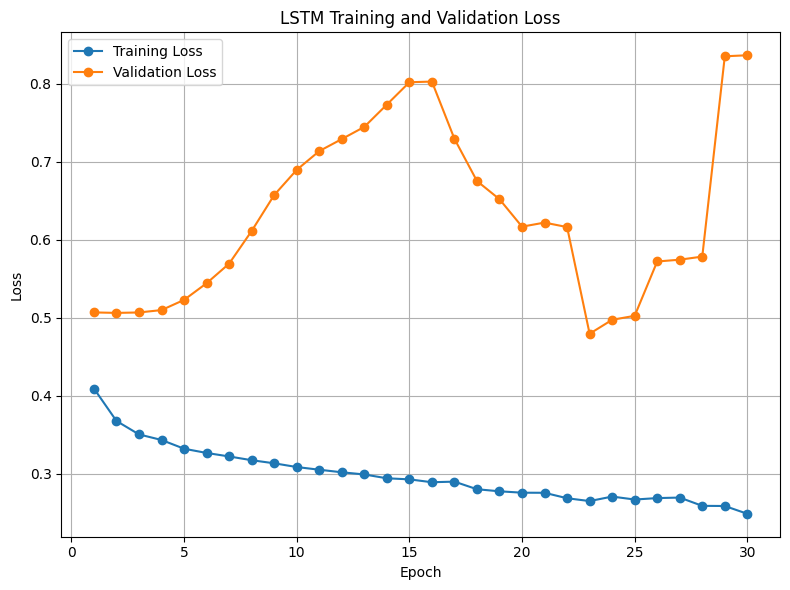

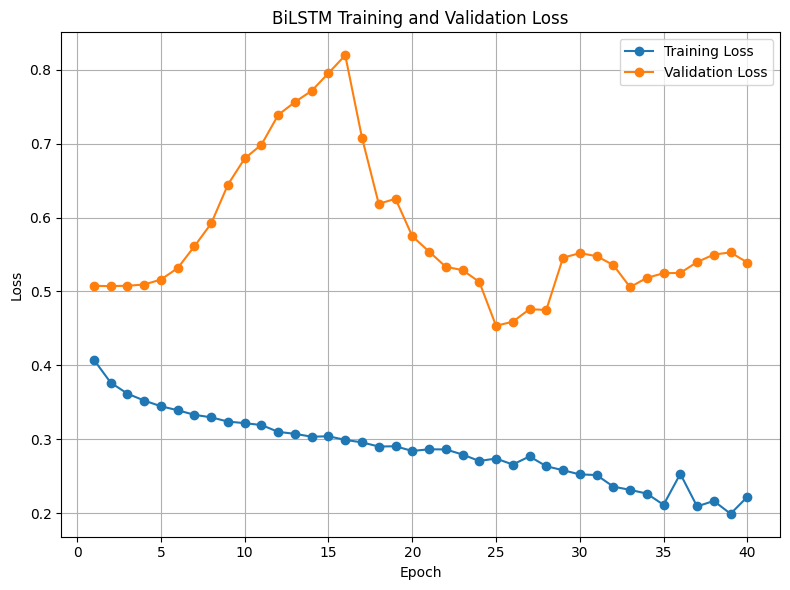

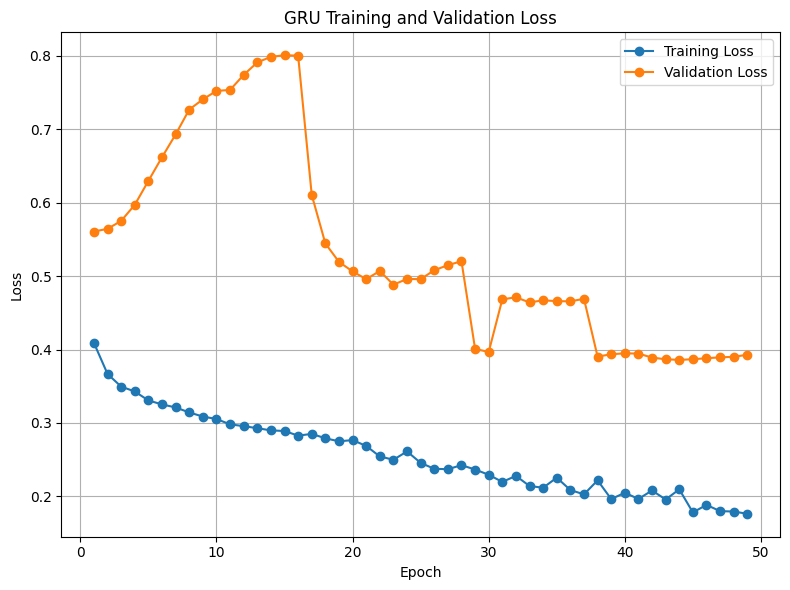

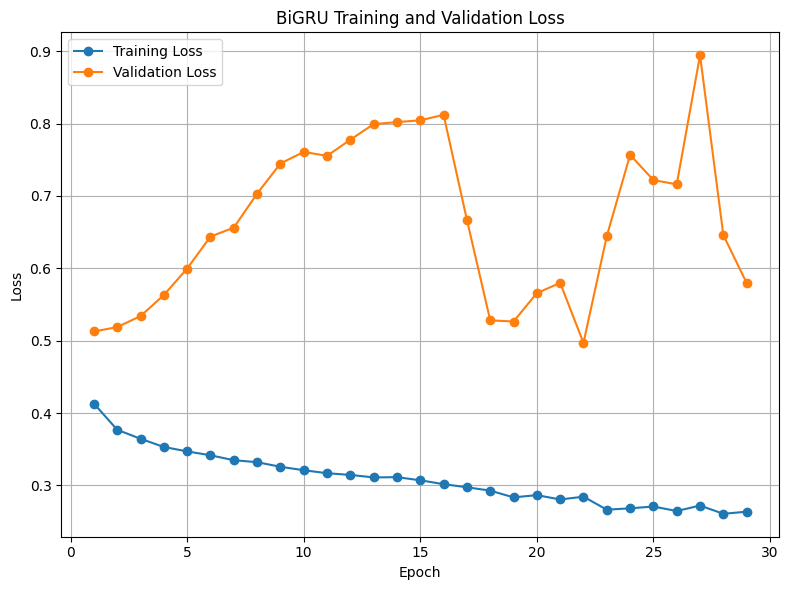

In [ ]:
for i, model_name in enumerate(models):
    csv_path = Path.joinpath(REGRESSION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)

    average_class_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(average_class_loss["epoch"], average_class_loss["train_loss"], label="Training Loss", marker='o')
    ax.plot(average_class_loss["epoch"], average_class_loss["val_loss"], label="Validation Loss", marker='o')
    ax.set_title(f"{model_name} Training and Validation Loss")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

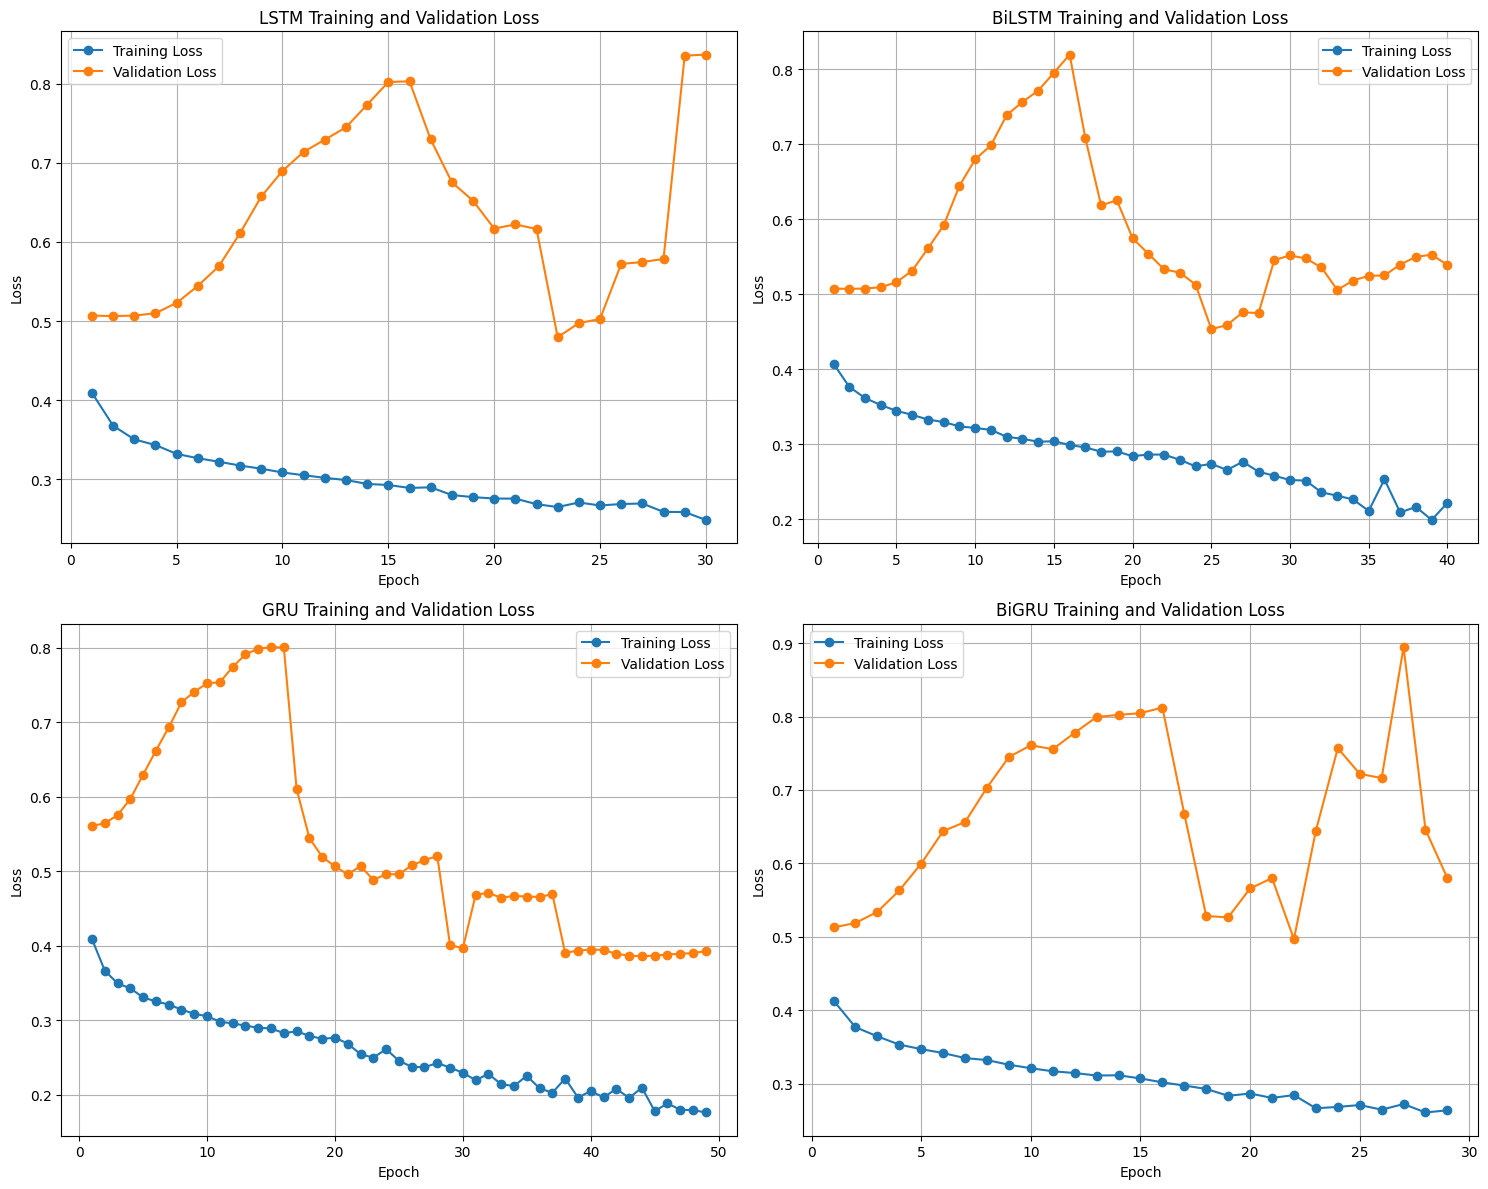

In [ ]:
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]

fig, axes = plt.subplots(2, 2, figsize=(15, 12)) 
axes = axes.flatten()

for i, model_name in enumerate(models):
    csv_path = Path.joinpath(REGRESSION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)

    average_regression_loss = df.groupby("epoch")[["train_loss", "val_loss"]].mean().reset_index()

    axes[i].plot(average_regression_loss["epoch"], average_regression_loss["train_loss"], label="Training Loss", marker='o')
    axes[i].plot(average_regression_loss["epoch"], average_regression_loss["val_loss"], label="Validation Loss", marker='o')
    axes[i].set_title(f"{model_name} Training and Validation Loss")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()

### Sector Specific


#### Classification

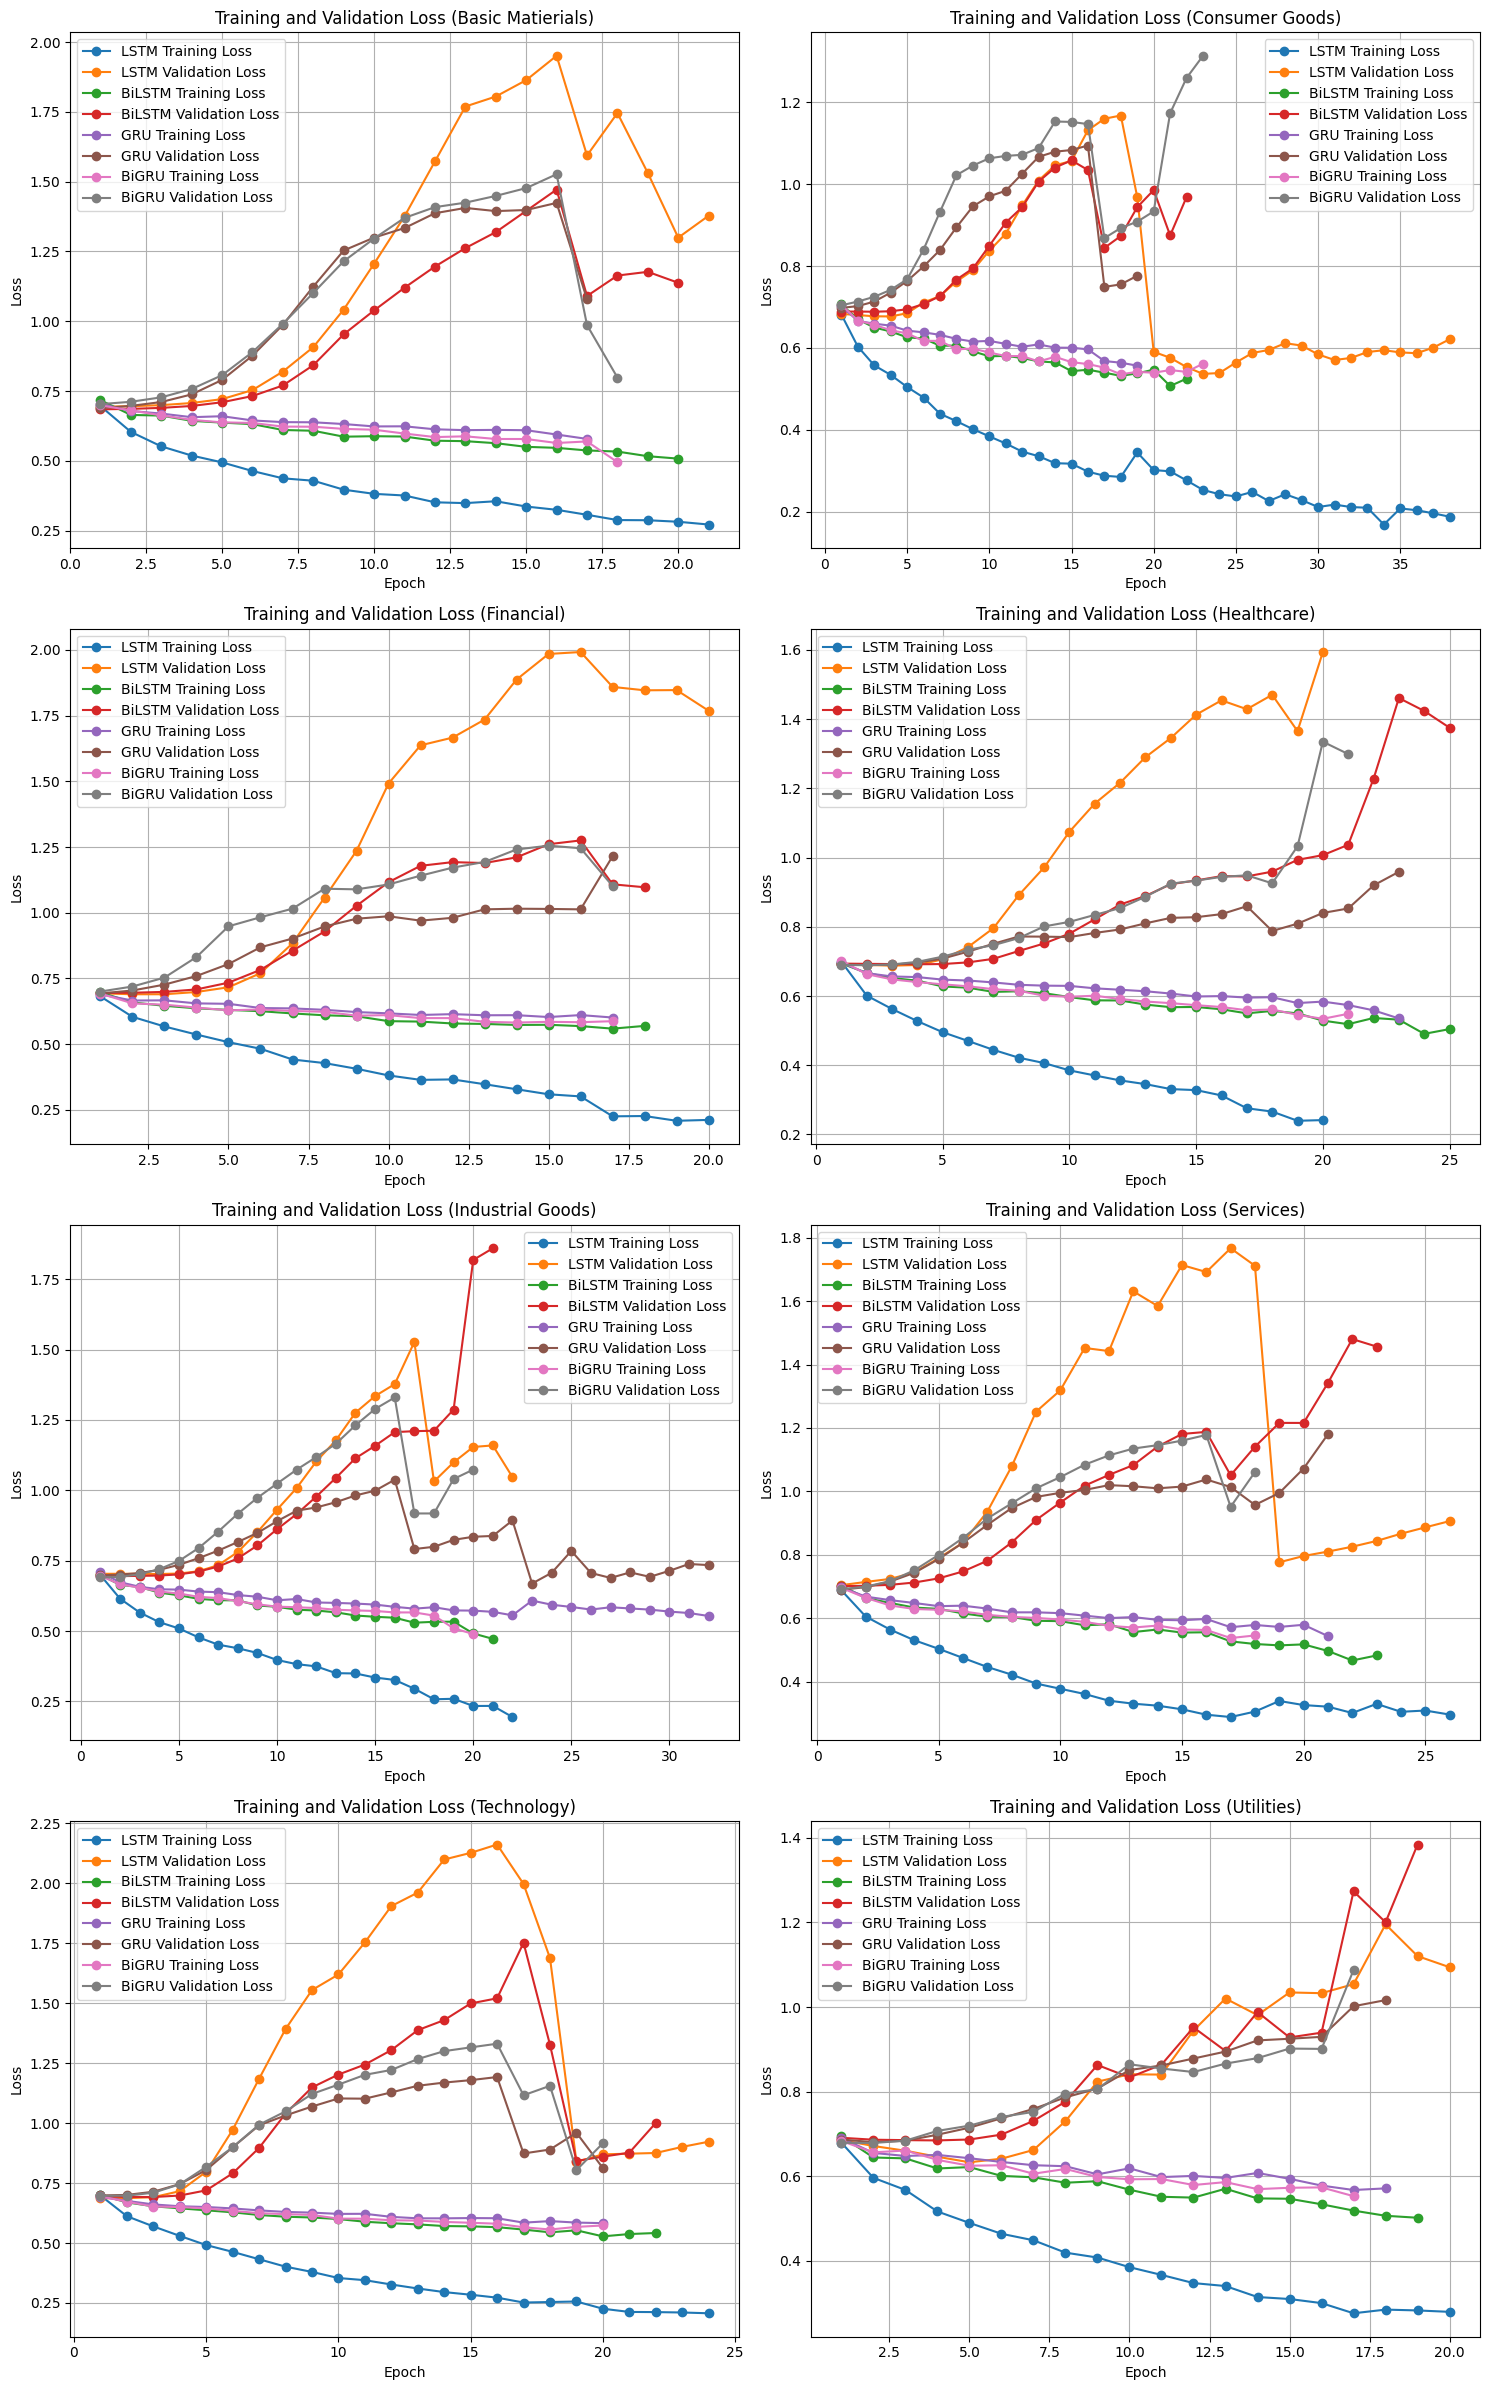

In [ ]:
# List of models to process
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]

# Combine data for all models
all_data = []
for model_name in models:
    csv_path = Path.joinpath(CLASSIFICATION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)
    df["model"] = model_name 
    all_data.append(df)

combined_df = pd.concat(all_data)

grouped_loss = combined_df.groupby(["sector", "model", "epoch"])[["train_loss", "val_loss"]].mean().reset_index()

sectors = grouped_loss["sector"].unique()
n_cols = 2 
n_rows = -(-len(sectors) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
axes = axes.flatten() 

for i, sector in enumerate(sectors):
    sector_data = grouped_loss[grouped_loss["sector"] == sector]
    
    for model_name in models:
        model_data = sector_data[sector_data["model"] == model_name]
        axes[i].plot(model_data["epoch"], model_data["train_loss"], label=f"{model_name} Training Loss", marker='o')
        axes[i].plot(model_data["epoch"], model_data["val_loss"], label=f"{model_name} Validation Loss", marker='o')
    
    axes[i].set_title(f"Training and Validation Loss ({sector})")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

for j in range(len(sectors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### Regression

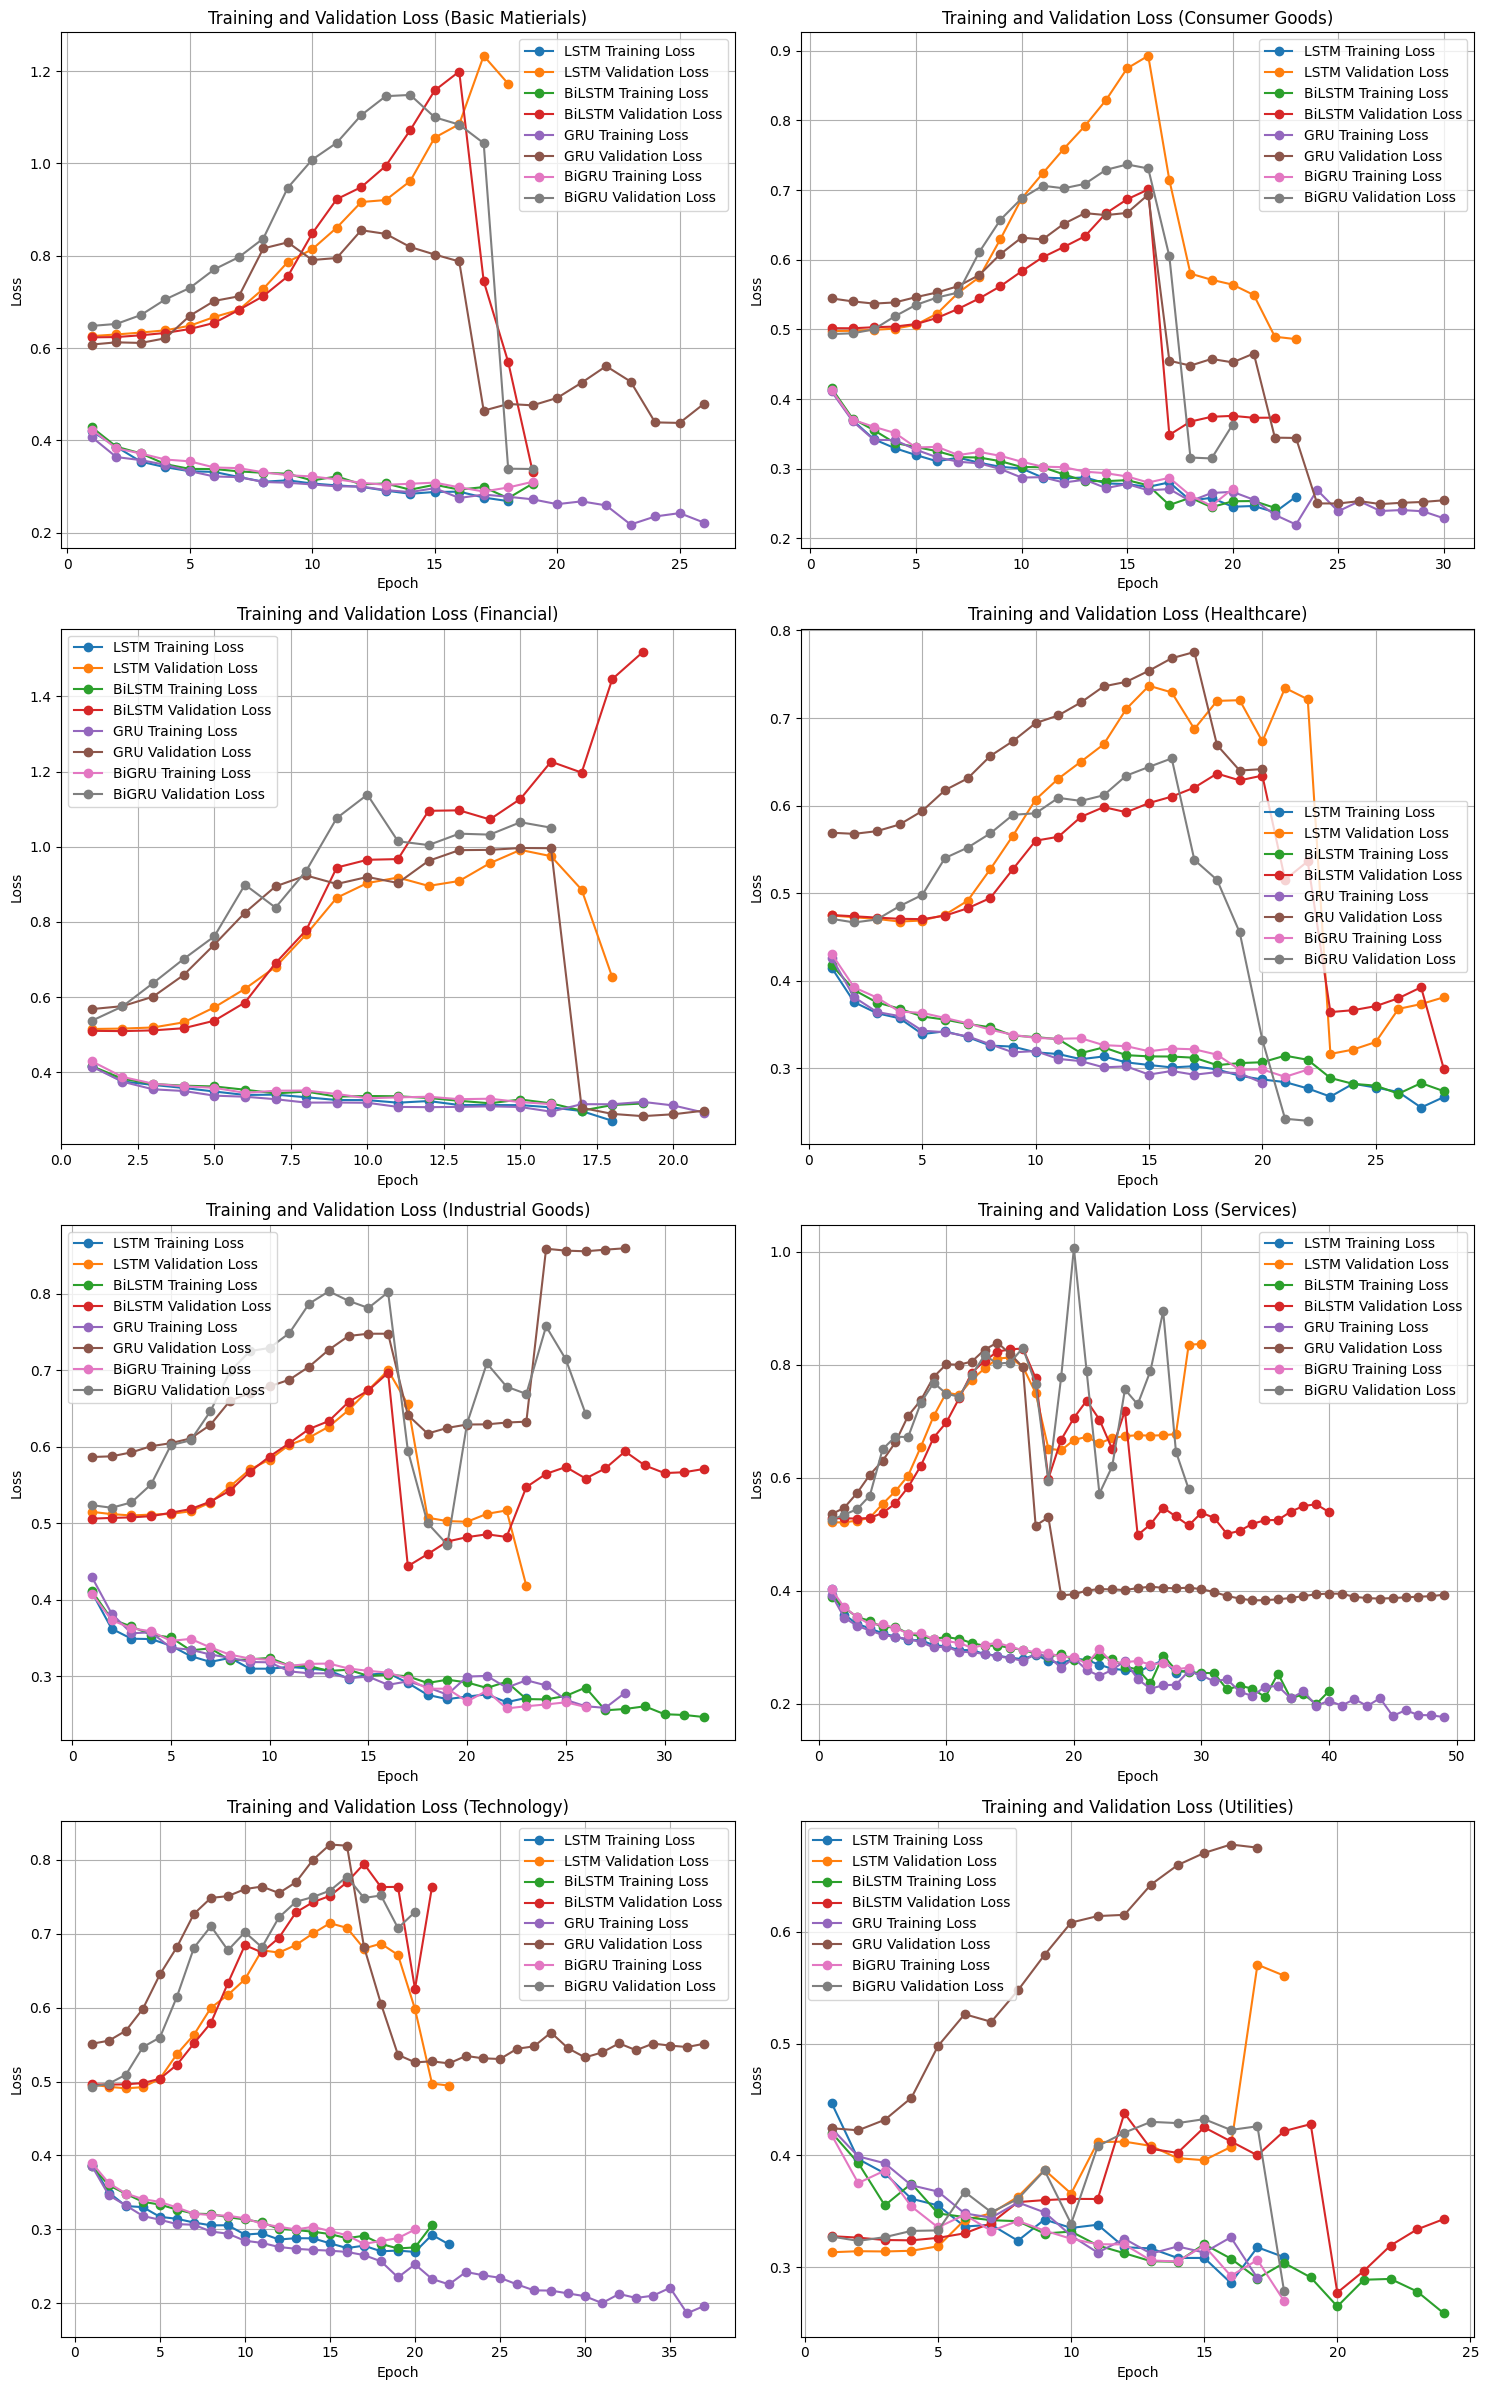

In [ ]:
# List of models to process
models = ["LSTM", "BiLSTM", "GRU", "BiGRU"]

# Combine data for all models
all_data = []
for model_name in models:
    csv_path = Path.joinpath(REGRESSION_RESULTS_PATH, f"{model_name}_loss_curves.csv")
    df = pd.read_csv(csv_path)
    df["model"] = model_name 
    all_data.append(df)

combined_df = pd.concat(all_data)

grouped_loss = combined_df.groupby(["sector", "model", "epoch"])[["train_loss", "val_loss"]].mean().reset_index()

sectors = grouped_loss["sector"].unique()
n_cols = 2 
n_rows = -(-len(sectors) // n_cols)  

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 6 * n_rows))
axes = axes.flatten() 

for i, sector in enumerate(sectors):
    sector_data = grouped_loss[grouped_loss["sector"] == sector]
    
    for model_name in models:
        model_data = sector_data[sector_data["model"] == model_name]
        axes[i].plot(model_data["epoch"], model_data["train_loss"], label=f"{model_name} Training Loss", marker='o')
        axes[i].plot(model_data["epoch"], model_data["val_loss"], label=f"{model_name} Validation Loss", marker='o')
    
    axes[i].set_title(f"Training and Validation Loss ({sector})")
    axes[i].set_xlabel("Epoch")
    axes[i].set_ylabel("Loss")
    axes[i].legend()
    axes[i].grid(True)

for j in range(len(sectors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Load the two Parquet files into DataFrames
df_bimeta = pd.read_parquet("stocknet-dataset/master_df_with_sector_and_bimeta_features.parquet")
df_meta = pd.read_parquet("stocknet-dataset/master_df_with_sector_and_meta_features.parquet")

print("Columns in df_bimeta:", df_bimeta.columns.tolist())
print("Columns in df_meta:", df_meta.columns.tolist())

columns_to_compare = [
    'up_1d_meta', 'has_meta_target', 'gru_pred_ret_1d', 'gru_err_ret_1d', 'gru_abs_err_ret_1d', 
    'gru_sq_err_ret_1d', 'gru_dir_correct_1d', 'gru_abs_err_lag1', 'gru_mae_20', 'gru_rmse_20', 
    'gru_dir_acc_20', 'lstm_prob_up_1d', 'lstm_logit_up_1d', 'lstm_brier', 'lstm_logloss', 
    'lstm_correct', 'lstm_brier_20', 'lstm_logloss_20', 'lstm_acc_20'
]

average_bimeta = df_bimeta[columns_to_compare].mean()
average_meta = df_meta[columns_to_compare].mean()

comparison_df = pd.DataFrame({
    "Column": columns_to_compare,
    "Average_BiMeta": average_bimeta.values,
    "Average_Meta": average_meta.values
})

print(comparison_df)

Columns in df_bimeta: ['date', 'open', 'high', 'low', 'close', 'adj close', 'volume', 'ticker', 'text', 'sentiment', 'emotion_anger', 'emotion_disgust', 'emotion_fear', 'emotion_joy', 'emotion_neutral', 'emotion_sadness', 'emotion_surprize', 'stance_positive', 'stance_negative', 'sector', 'company_name', 'EMA_12', 'EMA_26', 'EMA_50', 'MACD_12_26_9', 'MACDh_12_26_9', 'MACDs_12_26_9', 'RSI_14', 'STOCHRSIk_14_14_3_3', 'STOCHRSId_14_14_3_3', 'ATRr_14', 'BB_upper', 'BB_middle', 'BB_lower', 'OBV', 'ret_1d', 'roll_ret_1d', 'roll_ret_5d', 'roll_ret_20d', 'sector_open_mean', 'sector_high_mean', 'sector_low_mean', 'sector_close_mean', 'sector_volume_mean', 'sector_ret_1d', 'sector_ret_5d', 'sector_ret_20d', 'sector_range', 'sector_vol_20d', 'market_close', 'sector_rel_strength', 'sector_dispersion_1d', 'ret_1d_meta', 'up_1d_meta', 'has_meta_target', 'gru_pred_ret_1d', 'gru_err_ret_1d', 'gru_abs_err_ret_1d', 'gru_sq_err_ret_1d', 'gru_dir_correct_1d', 'gru_abs_err_lag1', 'gru_mae_20', 'gru_rmse_20

In [ ]:
# Ordered list of columns from the Optuna CSV
ordered_columns = [
    'number',
    'value',
    'datetime_start',
    'datetime_complete',
    'duration',
    'params_batch_size',
    'params_dropout',
    'params_early_stopping_patience',
    'params_feature_set',
    'params_hidden1',
    'params_hidden2',
    'params_horizon_steps',
    'params_inter_rnn_drop',
    'params_learning_rate',
    'params_lr_factor',
    'params_lr_patience',
    'params_max_epochs',
    'params_model_type',
    'params_num_layers',
    'params_sequence_length',
    'params_weight_decay',
    'user_attrs_val_directional_accuracy',
    'user_attrs_val_f1',
    'user_attrs_val_mcc',
    'user_attrs_val_precision',
    'user_attrs_val_recall',
    'state',
    'val_f1',
    'val_mcc',
    'val_precision',
    'val_recall',
    'val_directional_accuracy',
]

ordered_columns


['number',
 'value',
 'datetime_start',
 'datetime_complete',
 'duration',
 'params_batch_size',
 'params_dropout',
 'params_early_stopping_patience',
 'params_feature_set',
 'params_hidden1',
 'params_hidden2',
 'params_horizon_steps',
 'params_inter_rnn_drop',
 'params_learning_rate',
 'params_lr_factor',
 'params_lr_patience',
 'params_max_epochs',
 'params_model_type',
 'params_num_layers',
 'params_sequence_length',
 'params_weight_decay',
 'user_attrs_val_directional_accuracy',
 'user_attrs_val_f1',
 'user_attrs_val_mcc',
 'user_attrs_val_precision',
 'user_attrs_val_recall',
 'state',
 'val_f1',
 'val_mcc',
 'val_precision',
 'val_recall',
 'val_directional_accuracy']

In [ ]:
df_tuning = pd.read_csv("results/benchmarking/classification/optuna_tuning_basefeat_1H.csv")
df_tuning_display = df_tuning[['number', 'value', 'val_f1', 'params_model_type', 'params_batch_size', 'params_horizon_steps',
                                 'params_learning_rate', 'params_dropout', 'params_inter_rnn_drop', 'params_early_stopping_patience','params_num_layers',
                                 'params_sequence_length', 'params_hidden1', 'params_hidden2', 'params_feature_set',
                                 'params_max_epochs', 'params_weight_decay']]
df_tuning_display = df_tuning_display.round(6)
df_tuning_display.columns = ['Trial', 'F1 Score', 'Val F1', 'Model', 'Batch Size', 'Horizon Steps',
                               'Learning Rate', 'Dropout', 'Inter RNN Drop', 'Early Stopping Patience', 'Num Layers', 
                               'Sequence Length', 'Hidden1', 'Hidden2', 'Feature Set', 'Max Epochs', 'Weight Decay']
print(df_tuning_display.to_string(index=False))

 Trial  F1 Score   Val F1  Model  Batch Size  Horizon Steps  Learning Rate  Dropout  Inter RNN Drop  Early Stopping Patience  Num Layers  Sequence Length  Hidden1  Hidden2     Feature Set  Max Epochs  Weight Decay
   130  0.684133 0.684133    GRU          32              1       0.007164      0.4             0.0                       20           1               24      256       64 text_indicators          20      0.002128
   122  0.679082 0.679082 BiLSTM          32              1       0.007876      0.5             0.0                       20           1               24      256       64 text_indicators          20      0.006233
   129  0.678927 0.678927    GRU          32              1       0.007233      0.4             0.0                       20           1               24      256       64 text_indicators          20      0.001370
   121  0.678632 0.678632    GRU          32              1       0.008285      0.5             0.0                       20           1        

In [6]:
df_tuning = pd.read_csv("results/benchmarking/classification/optuna_tuning_sector_1H.csv")
df_tuning_display = df_tuning[['number', 'value', 'val_f1', 'params_model_type', 'params_batch_size', 'params_horizon_steps',
                                 'params_learning_rate', 'params_dropout', 'params_inter_rnn_drop', 'params_early_stopping_patience','params_num_layers',
                                 'params_sequence_length', 'params_hidden1', 'params_hidden2', 'params_feature_set',
                                 'params_max_epochs', 'params_weight_decay']]
df_tuning_display = df_tuning_display.round(6)
df_tuning_display.columns = ['Trial', 'F1 Score', 'Val F1', 'Model', 'Batch Size', 'Horizon Steps',
                               'Learning Rate', 'Dropout', 'Inter RNN Drop', 'Early Stopping Patience', 'Num Layers', 
                               'Sequence Length', 'Hidden1', 'Hidden2', 'Feature Set', 'Max Epochs', 'Weight Decay']
print(df_tuning_display.to_string(index=False))


 Trial  F1 Score   Val F1  Model  Batch Size  Horizon Steps  Learning Rate  Dropout  Inter RNN Drop  Early Stopping Patience  Num Layers  Sequence Length  Hidden1  Hidden2            Feature Set  Max Epochs  Weight Decay
    50  0.682122 0.682122    GRU          16              1       0.004179      0.0             0.3                       15           1               36      256      128      sector_indicators          20      0.000001
    86  0.678855 0.678855  BiGRU          16              1       0.002400      0.8             0.4                       15           2               36      128       64            sector_text          20      0.000000
    92  0.678783 0.678783  BiGRU          16              1       0.004228      0.8             0.4                       15           2               36      128       64            sector_text          20      0.000001
    95  0.678084 0.678084  BiGRU          16              1       0.003400      0.8             0.4                 

In [8]:
df_tuning = pd.read_csv("results/benchmarking/classification/optuna_tuning_basefeat.csv")
df_tuning_display = df_tuning[['number', 'value', 'val_f1', 'params_model_type', 'params_batch_size', 'params_horizon_steps',
                                 'params_learning_rate', 'params_dropout', 'params_inter_rnn_drop', 'params_early_stopping_patience','params_num_layers',
                                 'params_sequence_length', 'params_hidden1', 'params_hidden2', 'params_feature_set',
                                 'params_max_epochs', 'params_weight_decay']]
df_tuning_display = df_tuning_display.round(6)
df_tuning_display.columns = ['Trial', 'F1 Score', 'Val F1', 'Model', 'Batch Size', 'Horizon Steps',
                               'Learning Rate', 'Dropout', 'Inter RNN Drop', 'Early Stopping Patience', 'Num Layers', 
                               'Sequence Length', 'Hidden1', 'Hidden2', 'Feature Set', 'Max Epochs', 'Weight Decay']
print(df_tuning_display.to_string(index=False))


 Trial  F1 Score   Val F1  Model  Batch Size  Horizon Steps  Learning Rate  Dropout  Inter RNN Drop  Early Stopping Patience  Num Layers  Sequence Length  Hidden1  Hidden2     Feature Set  Max Epochs  Weight Decay
   140  0.715938 0.715938  BiGRU          16              5       0.001537      0.6             0.3                       20           2               36      256      128            base          50      0.000033
   133  0.711532 0.711532  BiGRU          16              5       0.001854      0.6             0.3                       20           2               36      256      128            base          50      0.000037
   102  0.711440 0.711440    GRU          32              5       0.001982      0.6             0.3                       20           1               18      256      128 text_indicators          20      0.000005
   136  0.711175 0.711175  BiGRU          16              5       0.001907      0.6             0.3                       20           2        

In [9]:
df_tuning = pd.read_csv("results/benchmarking/classification/optuna_tuning_sector.csv")
df_tuning_display = df_tuning[['number', 'value', 'val_f1', 'params_model_type', 'params_batch_size', 'params_horizon_steps',
                                 'params_learning_rate', 'params_dropout', 'params_inter_rnn_drop', 'params_early_stopping_patience','params_num_layers',
                                 'params_sequence_length', 'params_hidden1', 'params_hidden2', 'params_feature_set',
                                 'params_max_epochs', 'params_weight_decay']]
df_tuning_display = df_tuning_display.round(6)
df_tuning_display.columns = ['Trial', 'F1 Score', 'Val F1', 'Model', 'Batch Size', 'Horizon Steps',
                               'Learning Rate', 'Dropout', 'Inter RNN Drop', 'Early Stopping Patience', 'Num Layers', 
                               'Sequence Length', 'Hidden1', 'Hidden2', 'Feature Set', 'Max Epochs', 'Weight Decay']
print(df_tuning_display.to_string(index=False))


 Trial  F1 Score   Val F1  Model  Batch Size  Horizon Steps  Learning Rate  Dropout  Inter RNN Drop  Early Stopping Patience  Num Layers  Sequence Length  Hidden1  Hidden2            Feature Set  Max Epochs  Weight Decay
   161  0.714383 0.714383  BiGRU          32              5       0.004013      0.8             0.0                       20           1               24      256       64      sector_indicators          30      0.000006
   188  0.711982 0.711982  BiGRU          32              5       0.002833      0.8             0.4                       20           1               24      256       64      sector_indicators          20      0.000037
   189  0.710634 0.710634  BiGRU          32              5       0.002441      0.8             0.4                       20           1               24      256       64      sector_indicators          20      0.000023
   165  0.710058 0.710058  BiGRU          32              5       0.002716      0.8             0.4                 

In [ ]:
df_tuning = pd.read_csv("results/benchmarking/regression/optuna_tuning_basefeat.csv")
df_tuning_display = df_tuning[['number', 'value', 'params_model_type', 'params_batch_size', 'params_horizon_steps',
                                 'params_learning_rate', 'params_dropout', 'params_inter_rnn_drop', 'params_early_stopping_patience','params_num_layers',
                                 'params_sequence_length', 'params_hidden1', 'params_hidden2', 'params_feature_set',
                                 'params_max_epochs', 'params_weight_decay']]
df_tuning_display = df_tuning_display.round(6)
df_tuning_display.columns = ['Trial', '-MAE', 'Model', 'Batch Size', 'Horizon Steps',
                               'Learning Rate', 'Dropout', 'Inter RNN Drop', 'Early Stopping Patience', 'Num Layers', 
                               'Sequence Length', 'Hidden1', 'Hidden2', 'Feature Set', 'Max Epochs', 'Weight Decay']
print(df_tuning_display.to_string(index=False))


 Trial      -MAE  Model  Batch Size  Horizon Steps  Learning Rate  Dropout  Inter RNN Drop  Early Stopping Patience  Num Layers  Sequence Length  Hidden1  Hidden2     Feature Set  Max Epochs  Weight Decay
   105 -0.011397   LSTM          32              1       0.000010      0.0             0.4                       15           2               18       64       32 text_indicators          50      0.000440
   240 -0.011414 BiLSTM          64              1       0.000014      0.1             0.3                       10           2               18      128       64 text_indicators          20      0.008200
   210 -0.011421 BiLSTM          64              1       0.000018      0.2             0.3                       10           2               18      128       64 text_indicators          20      0.006717
   218 -0.011421 BiLSTM          64              1       0.000014      0.2             0.3                       10           2               18      128       64 text_indicators  

In [7]:
df_tuning = pd.read_csv("results/benchmarking/regression/optuna_tuning_sector.csv")
df_tuning_display = df_tuning[['number', 'value', 'params_model_type', 'params_batch_size', 'params_horizon_steps',
                                 'params_learning_rate', 'params_dropout', 'params_inter_rnn_drop', 'params_early_stopping_patience','params_num_layers',
                                 'params_sequence_length', 'params_hidden1', 'params_hidden2', 'params_feature_set',
                                 'params_max_epochs', 'params_weight_decay']]
df_tuning_display = df_tuning_display.round(6)
df_tuning_display.columns = ['Trial', '-MAE', 'Model', 'Batch Size', 'Horizon Steps',
                               'Learning Rate', 'Dropout', 'Inter RNN Drop', 'Early Stopping Patience', 'Num Layers', 
                               'Sequence Length', 'Hidden1', 'Hidden2', 'Feature Set', 'Max Epochs', 'Weight Decay']
print(df_tuning_display.to_string(index=False))


 Trial      -MAE  Model  Batch Size  Horizon Steps  Learning Rate  Dropout  Inter RNN Drop  Early Stopping Patience  Num Layers  Sequence Length  Hidden1  Hidden2            Feature Set  Max Epochs  Weight Decay
   190 -0.011453    GRU          64              1       0.000153      0.8             0.4                       15           2               18       64       64      sector_indicators          20      0.000026
   223 -0.011467    GRU          64              1       0.000154      0.8             0.4                       15           2               18       64       64      sector_indicators          20      0.000618
   164 -0.011469    GRU          64              1       0.000114      0.8             0.4                       20           2               18       64       64      sector_indicators          20      0.000555
   152 -0.011485    GRU          64              1       0.000156      0.7             0.4                       15           2               18       6